# Examen Python data developer
# Deel 1
## Introductie
Voor dit examen is het belangrijk dat je volgende zaken zeker doet:
 - Maak een Vitual Environment aan & exporteer een `.yml` (of soortgelijke) file aan die je toevoegt aan je codebase.
 - Maak een github pagina aan met een bijhorende `.gitignore` en `readme.md`. Voeg een link naar de github repo toe aan je readme file.
 - Zorg dat je op het einde de tijd neemt om je code op te schonen zodat deze begrijpelijk is voor derden.
 - Wanneer je klaar bent, maak een `.zip` bestand van je volledige codebase aan en laad deze op in de leeromgeving.

In deze opgave bekijken we een gesimuleerde dataset over de geboortes in België van 2019. De data is te vinden in `.csv` bestanden die gelabeld zijn met de echte geboortedag van de personen in het bestand. Laat ons bijvoorbeeld even kijken naar de eerste 5 lijnen van het bestand `2019-1-1.csv`:

<table align="center">
  <tr>
    <th>gemeente</th>
    <th>naam</th>
    <th>geslacht</th>
    <th>verwachte datum</th>
  </tr>
  <tr>
    <td>Hooglede</td>
    <td>Elias</td>
    <td>Mannelijk</td>
    <td>01/14/2019</td>
  </tr>
  <tr>
    <td>Sint-Niklaas (Sint-Niklaas)</td>
    <td>Pauline</td>
    <td>Vrouwelijk</td>
    <td>01/05/2019</td>
  </tr>
  <tr>
    <td>Wijnegem</td>
    <td>Anita</td>
    <td>Vrouwelijk</td>
    <td>01/05/2019</td>
  </tr>
  <tr>
    <td>Grâce-Hollogne</td>
    <td>Jean-Paul</td>
    <td>Mannelijk</td>
    <td>01/13/2019</td>
  </tr>
  <tr>
    <td>Boussu</td>
    <td>François</td>
    <td>Mannelijk</td>
    <td>01/26/2019</td>
  </tr>
</table>


Hier hebben we de kolommen:
 - **gemeente**: De gemeente waar de persoon geboren is.
 - **naam**: De voornaam van de persoon.
 - **geslacht**: Het geslacht van de persoon (Mannelijk of Vrouwelijk).
 - **verwachte datum**: De verwachte geboortedatum van de persoon.

Dus hier hebben we dan bijvoorbeeld op de eerste lijn de mannelijke persoon Elias die geboren is in Hooglede waarvan men verwachtte dat hij zou geboren worden op `01/14/2019` (Amerikaans formaat) maar in feite geboren is op 1 januari 2019.

Doorheen deze opgave gaan we de data van dichterbij inspecteren! Je kan deze opgaves alternatief lezen in de bijgeleverde notebook `examen.ipynb` waar ook de (meeste) afbeeldingen & resultaten zichtbaar zijn.

## Visualisaties

Wanneer er je gevraagd wordt een visualisatie te maken krijg je minimale instructies. Tijdens de lessenreeks zagen we een heel aantal best practices, pas deze toe ook al wordt dit niet telkens expliciet aangegeven in de instructies.


## Puntenverdeling
**Het totale examen staat op X punten.**

Mondelinge toelichting voor alles
 - 50%: Je snapt wat je gedaan hebt.
 - 50%: Je kan bijvragen beantwoorden

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import stats
from sklearn.linear_model import LinearRegression
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)

In [2]:
DATA_DIR = Path("data")

## Utilities

In [3]:
def get_season(month):
    """Geeft seizoen terug op basis van maandnummer."""
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Lente'
    elif month in [6, 7, 8]:
        return 'Zomer'
    else:
        return 'Herfst'

SEASON_ORDER = ['Winter', 'Lente', 'Zomer', 'Herfst']
DAY_ORDER = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

## Stap 1: data inlezen (1 pnt)

Bouw één DataFrame `df_births` met alle geboortes uit de map `data/geboortes`.

**Output**
- `df_births` bevat alle rijen uit alle CSV-bestanden.
- `df_births` bevat een kolom `date` als echte datetime (`YYYY-MM-DD`), afgeleid uit de bestandsnaam.
- `df_births` bevat een kolom `dag_van_jaar` met waarden van 1 tot 365.
- De observatie-grain is identiek aan de bron: **1 rij = 1 geboorte**.

**Te tonen checks**
- Aantal rijen in `df_births`
- Minimum- en maximumdatum
- Minimum en maximum van `day_of_year`
- Geen onbestaande datums (bv. dag 0, dag 32, 29/2 in niet-schrikkeljaren, geboortejaar 2027,...)

---

In [6]:
frames = []
invalid_files = []
for csv_file in sorted(DATA_DIR.glob("*.csv")):
    parts = csv_file.stem.split("-")
    try:
        date = pd.Timestamp(int(parts[0]), int(parts[1]), int(parts[2]))
    except ValueError:
        invalid_files.append(csv_file.name)
        continue
    df_tmp = pd.read_csv(csv_file)
    df_tmp["date"] = date
    frames.append(df_tmp)

df_births = pd.concat(frames, ignore_index=True)
df_births["dag_van_jaar"] = df_births["date"].dt.dayofyear
df_births["verwachte datum"] = pd.to_datetime(df_births["verwachte datum"], format="%m/%d/%Y")

if invalid_files:
    print(f"⚠ Overgeslagen (ongeldige datum): {invalid_files}")
print(f"Shape: {df_births.shape}")
df_births.head()

⚠ Overgeslagen (ongeldige datum): ['2019-2-29.csv']
Shape: (116850, 6)


,gemeente,naam,geslacht,verwachte datum,date,dag_van_jaar
0,Hooglede,Elias,Mannelijk,2019-01-14,2019-01-01,1
1,Sint-Niklaas (Sint-Niklaas),Pauline,Vrouwelijk,2019-01-05,2019-01-01,1
2,Wijnegem,Anita,Vrouwelijk,2019-01-05,2019-01-01,1
3,Grâce-Hollogne,Jean-Paul,Mannelijk,2019-01-13,2019-01-01,1
4,Boussu,François,Mannelijk,2019-01-26,2019-01-01,1


In [ ]:
print(f"Aantal rijen:     {len(df_births)}")
print(f"Min datum:        {df_births['date'].min().date()}")
print(f"Max datum:        {df_births['date'].max().date()}")
print(f"Min dag_van_jaar: {df_births['dag_van_jaar'].min()}")
print(f"Max dag_van_jaar: {df_births['dag_van_jaar'].max()}")
print(f"Unieke datums:    {df_births['date'].nunique()}")
print(f"Jaar range:       {sorted(df_births['date'].dt.year.unique())}")

all_days = set(range(1, 366))
present_days = set(df_births['dag_van_jaar'].unique())
missing = all_days - present_days
print(f"Ontbrekende dagen: {missing if missing else 'Geen'}")

## Stap 2: EDA

### Vraag 1: Initial Plot

Maak een plot van het aantal geboortes per dag van het jaar. Gebruik een horizontale rode stippellijn om het gemiddelde aan te geven. (1 pnt)

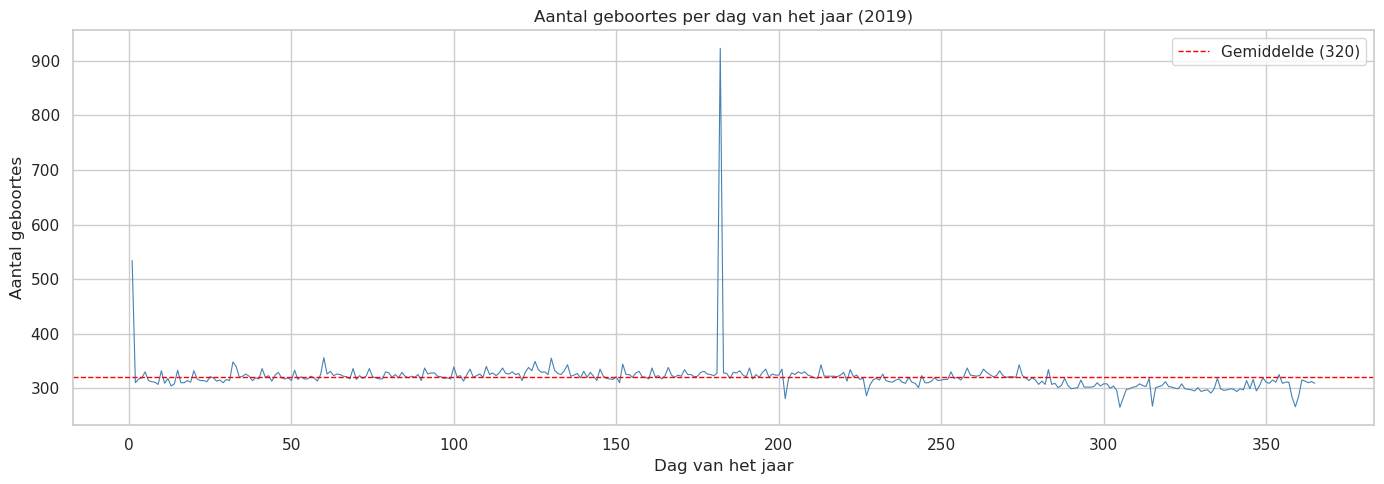

In [7]:
births_per_day = df_births.groupby("dag_van_jaar").size()
mean_births = births_per_day.mean()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(births_per_day.index, births_per_day.values, linewidth=0.8, color='steelblue')
ax.axhline(mean_births, color='red', linestyle='--', linewidth=1, label=f'Gemiddelde ({mean_births:.0f})')
ax.set_xlabel("Dag van het jaar")
ax.set_ylabel("Aantal geboortes")
ax.set_title("Aantal geboortes per dag van het jaar (2019)")
ax.legend()
plt.tight_layout()
plt.show()

### Vraag 2: Outliers vinden & behandelen

#### Vraag 2.1 Zoek alle outliers in de dataset. (1 pnt)

Kies een regel om een datapunt als 'outlier' te classifieren, pas deze toe en verdedig je keuze.

In [13]:
# Outlier-detectie met z-scores (|z| > 3 = extreme uitschieters)
mean_val = births_per_day.mean()
std_val = births_per_day.std()
z_scores = (births_per_day - mean_val) / std_val

outlier_days = births_per_day[z_scores.abs() > 3]

print(f"Gemiddelde = {mean_val:.1f}, Std = {std_val:.1f}")
print(f"Drempel: |z| > 3  →  buiten [{mean_val - 3*std_val:.0f}, {mean_val + 3*std_val:.0f}]")
print(f"\nAantal outlier-dagen: {len(outlier_days)}\n")
for day, count in outlier_days.sort_values().items():
    z = z_scores[day]
    date = pd.Timestamp('2019-01-01') + pd.Timedelta(days=int(day)-1)
    print(f"  Dag {day:3d} ({date.strftime('%Y-%m-%d')}, {date.strftime('%A'):>9s}): {count} geboortes  (z = {z:.1f})")

Gemiddelde = 320.1, Std = 35.9
Drempel: |z| > 3  →  buiten [212, 428]

Aantal outlier-dagen: 2

  Dag   1 (2019-01-01,   Tuesday): 534 geboortes  (z = 6.0)
  Dag 182 (2019-07-01,    Monday): 923 geboortes  (z = 16.8)


#### Vraag 2.2 Outlier remediation (1 pnt)
Je stelt vast dat twee dagen eruit springen als outliers. Corrigeer en voeg foute rijen toe aan `df_wrong` met een duidelijk omschreven reden. Documenteer in een comment welk patroon je opmerkte en  verdedig je correctiestrategie. Hermaak ten slotte de figuur uit Vraag 1 op basis van `df_births_clean`.


Twee meest extreme dagen:
dag_van_jaar
182    923
1      534
dtype: int64

df_wrong: 1457 rijen verwijderd
df_births_clean: 115393 rijen over


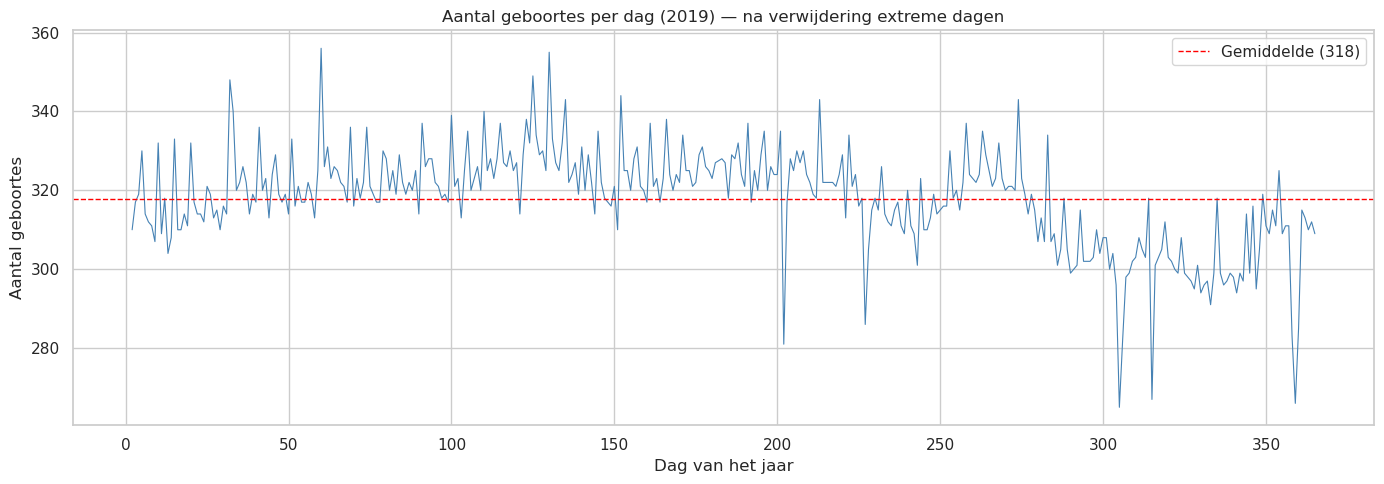

In [14]:
# Patroon: De 2 meest extreme dagen (hoogste outliers) vallen ver boven de bovengrens.
# Dit wijst op datacorruptie (bv. dubbele registratie of fout in simulatie).
# Strategie: verwijder de rijen van die 2 extreme dagen en bewaar ze in df_wrong.

extreme_2 = outlier_days.nlargest(2)
print("Twee meest extreme dagen:")
print(extreme_2)

extreme_dates = []
for day in extreme_2.index:
    date = pd.Timestamp('2019-01-01') + pd.Timedelta(days=int(day)-1)
    extreme_dates.append(date)

mask_wrong = df_births['date'].isin(extreme_dates)
df_wrong = df_births[mask_wrong].copy()
df_wrong['reden'] = 'Extreem hoog aantal geboortes — vermoedelijk datacorruptie (dubbele registratie)'

df_births_clean = df_births[~mask_wrong].copy()
print(f"\ndf_wrong: {len(df_wrong)} rijen verwijderd")
print(f"df_births_clean: {len(df_births_clean)} rijen over")

# Hermaak de figuur uit Vraag 1
births_per_day_clean = df_births_clean.groupby("dag_van_jaar").size()
mean_clean = births_per_day_clean.mean()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(births_per_day_clean.index, births_per_day_clean.values, linewidth=0.8, color='steelblue')
ax.axhline(mean_clean, color='red', linestyle='--', linewidth=1, label=f'Gemiddelde ({mean_clean:.0f})')
ax.set_xlabel("Dag van het jaar")
ax.set_ylabel("Aantal geboortes")
ax.set_title("Aantal geboortes per dag (2019) — na verwijdering extreme dagen")
ax.legend()
plt.tight_layout()
plt.show()

#### Vraag 2.3 Identificeer de **8 meest extreme** dagen in de tweede helft van het jaar. (1 pnt)

In [15]:
# Tweede helft van het jaar: dag 183 (2 juli) t.e.m. dag 365
h2 = births_per_day_clean[births_per_day_clean.index >= 183]

# Afwijking t.o.v. mediaan (robuuster dan gemiddelde)
median_h2 = h2.median()
deviation = (h2 - median_h2).abs()
extreme_8 = deviation.nlargest(8)

result = pd.DataFrame({
    'dag_van_jaar': extreme_8.index,
    'geboortes': h2[extreme_8.index].values,
    'afwijking': extreme_8.values
})
result['datum'] = result['dag_van_jaar'].apply(
    lambda d: (pd.Timestamp('2019-01-01') + pd.Timedelta(days=int(d)-1)).strftime('%Y-%m-%d (%A)')
)
result = result[['dag_van_jaar', 'datum', 'geboortes', 'afwijking']]
result

,dag_van_jaar,datum,geboortes,afwijking
0,305,2019-11-01 (Friday),265,49.0
1,359,2019-12-25 (Wednesday),266,48.0
2,315,2019-11-11 (Monday),267,47.0
3,202,2019-07-21 (Sunday),281,33.0
4,306,2019-11-02 (Saturday),282,32.0
5,358,2019-12-24 (Tuesday),283,31.0
6,213,2019-08-01 (Thursday),343,29.0
7,274,2019-10-01 (Tuesday),343,29.0


### Vraag 3: Verbanden per week/maand

#### Vraag 3.1 (2 pnt)
We zien vele pieken en dalen in de evolutie van het aantal geboortes. We willen deze grafiek graag iets "gladder" maken. Kan je hiervoor eens een visualizatie maken van het **gemiddeld** aantal geboortes per week (dit voor elke week, dus maandag-maandag, dinsdag-dinsdag, woensdag-woensdag, ...).


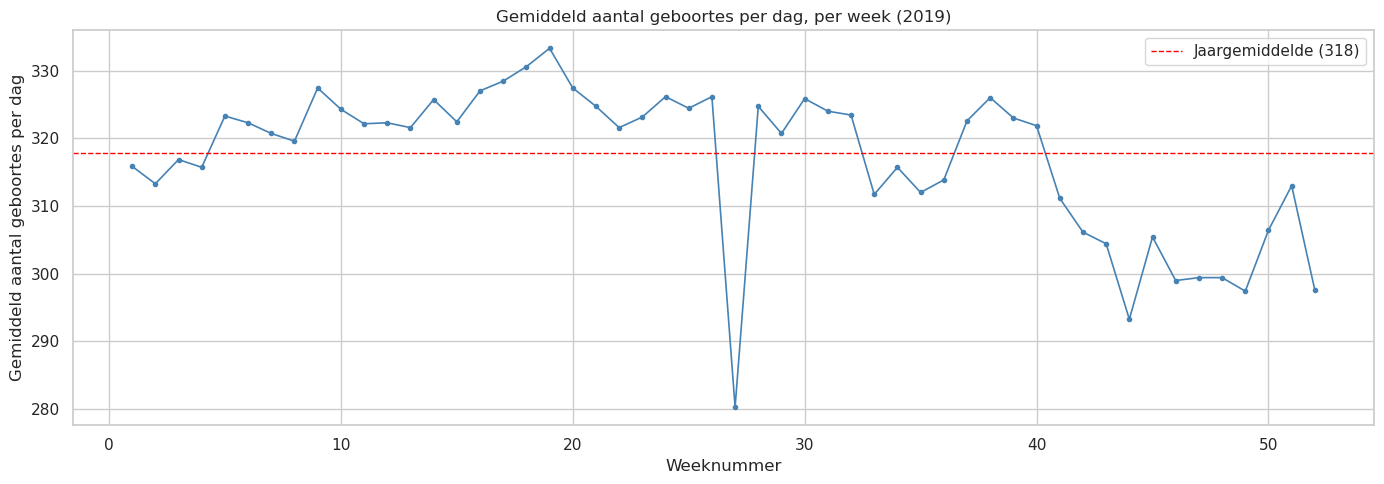

In [16]:
# Week = groep van 7 opeenvolgende dagen (ISO week)
df_births_clean['week'] = df_births_clean['date'].dt.isocalendar().week.astype(int)
births_per_week = df_births_clean.groupby('week').size()
avg_per_week = births_per_week / 7  # gemiddeld per dag per week

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(avg_per_week.index, avg_per_week.values, linewidth=1.2, color='steelblue', marker='o', markersize=3)
ax.axhline(births_per_day_clean.mean(), color='red', linestyle='--', linewidth=1, label=f'Jaargemiddelde ({births_per_day_clean.mean():.0f})')
ax.set_xlabel("Weeknummer")
ax.set_ylabel("Gemiddeld aantal geboortes per dag")
ax.set_title("Gemiddeld aantal geboortes per dag, per week (2019)")
ax.legend()
plt.tight_layout()
plt.show()

#### Vraag 3.2 (2 pnt)
Dat ziet er al een stuk mooier uit!  We zien ook een aantal duidelijk dips & pieken verschijnen die we eerder niet zagen. We kunnen nu ook even kijken naar het gemiddeld aantal geboortes per dag van de week! Misschien worden er wel gewoon veel minder mensen geboren op zondag dan een andere dag?

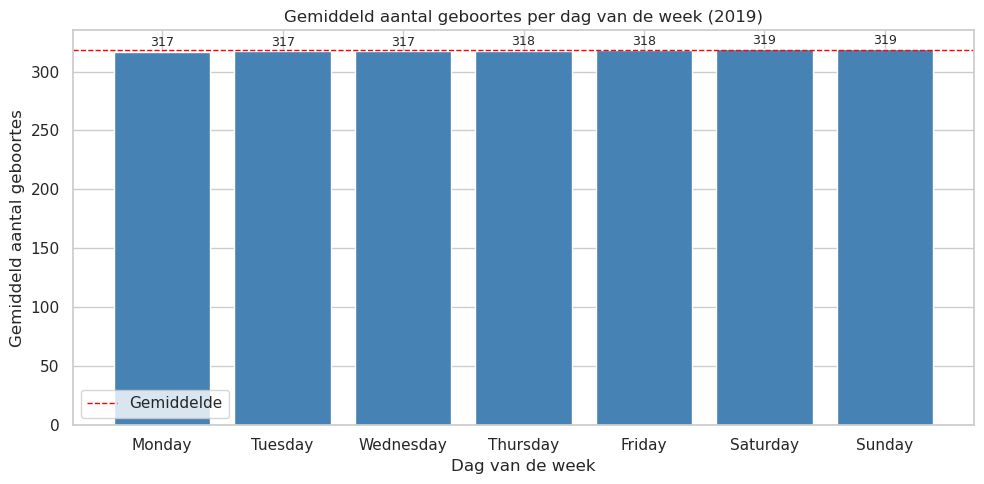

In [17]:
df_births_clean['weekday'] = df_births_clean['date'].dt.day_name()
daily_counts = df_births_clean.groupby(['date', 'weekday']).size().reset_index(name='n_births')
avg_by_weekday = daily_counts.groupby('weekday')['n_births'].mean().reindex(DAY_ORDER)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(avg_by_weekday.index, avg_by_weekday.values, color='steelblue', edgecolor='white')
ax.axhline(avg_by_weekday.mean(), color='red', linestyle='--', linewidth=1, label='Gemiddelde')
ax.set_xlabel("Dag van de week")
ax.set_ylabel("Gemiddeld aantal geboortes")
ax.set_title("Gemiddeld aantal geboortes per dag van de week (2019)")
ax.legend()
for bar, val in zip(bars, avg_by_weekday.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2, f'{val:.0f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

#### Vraag 3.3 — Maandverschillen in geboortes (3pnt)

Je beschikt over geboortecijfers per dag voor één kalenderjaar.

Maak één visualisatie die het gemiddeld aantal geboortes per maand toont
en tegelijk toelaat om de variatie binnen elke maand te vergelijken.

De visualisatie moet:
- de maanden tonen in chronologische volgorde (januari → december)
- per maand het gemiddelde aantal geboortes tonen
- per maand de onzekerheid rond dat gemiddelde tonen op 95% betrouwbaarheid en gebaseerd op de dagwaarden (niet handmatig berekend)



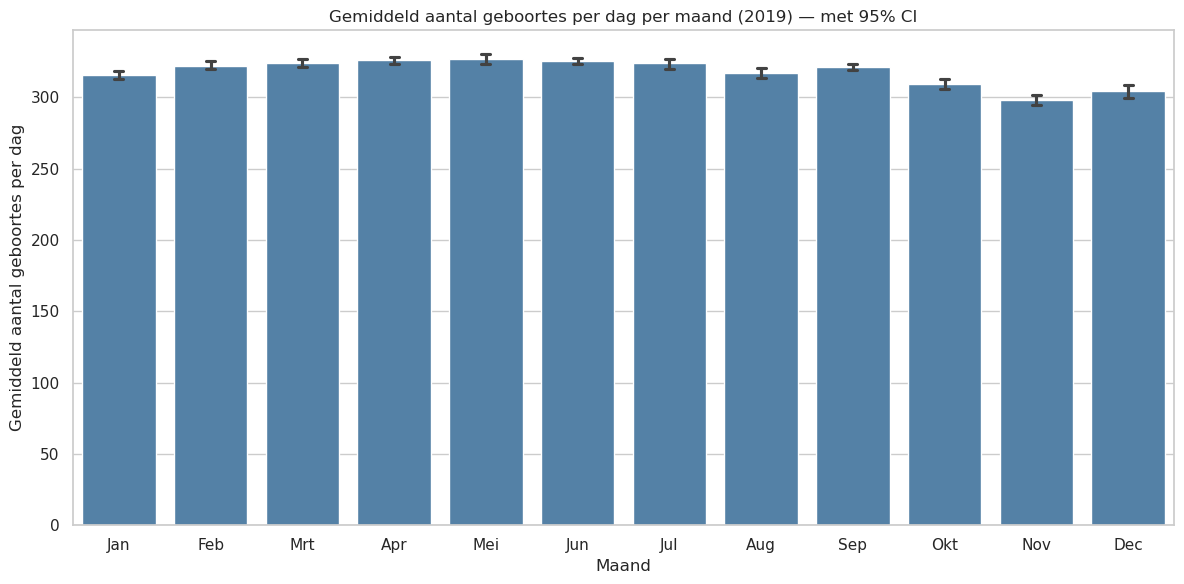

In [18]:
df_births_clean['month'] = df_births_clean['date'].dt.month
daily_counts_m = df_births_clean.groupby(['date', 'month']).size().reset_index(name='n_births')
daily_counts_m['maand'] = daily_counts_m['month'].map({
    1:'Jan',2:'Feb',3:'Mrt',4:'Apr',5:'Mei',6:'Jun',
    7:'Jul',8:'Aug',9:'Sep',10:'Okt',11:'Nov',12:'Dec'
})
month_order = ['Jan','Feb','Mrt','Apr','Mei','Jun','Jul','Aug','Sep','Okt','Nov','Dec']

fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(data=daily_counts_m, x='maand', y='n_births', order=month_order,
            ci=95, capsize=0.1, color='steelblue', ax=ax)
ax.set_xlabel("Maand")
ax.set_ylabel("Gemiddeld aantal geboortes per dag")
ax.set_title("Gemiddeld aantal geboortes per dag per maand (2019) — met 95% CI")
plt.tight_layout()
plt.show()

#### Vraag 3.2 Weekdag en seizoen (4 pnt)

Je beschikt over geboortecijfers per dag voor één kalenderjaar.

Onderzoek of het effect van de dag van de week op het aantal geboortes constant is doorheen het jaar of verschilt naargelang het seizoen.

Maak één visualisatie die:
- verschillen tussen weekdagen toont
- toelaat om deze verschillen over het jaar te vergelijken
- leesbaar blijft zonder aparte grafieken per maand of weekdag



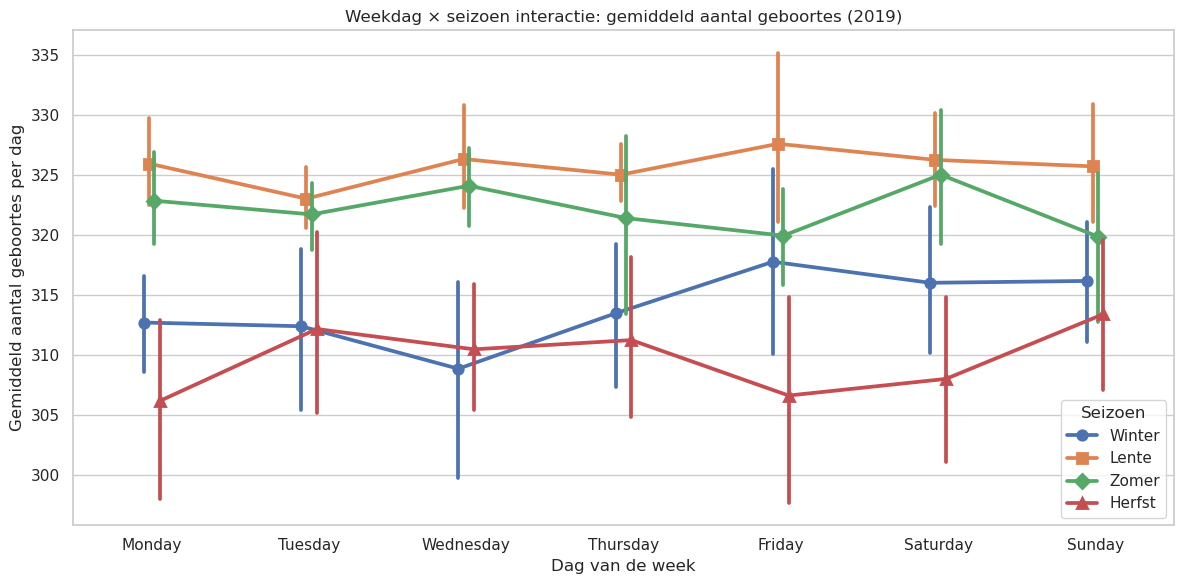

In [19]:
df_births_clean['season'] = df_births_clean['date'].dt.month.map(get_season)

daily_season = df_births_clean.groupby(['date', 'weekday', 'season']).size().reset_index(name='n_births')

fig, ax = plt.subplots(figsize=(12, 6))
sns.pointplot(data=daily_season, x='weekday', y='n_births', hue='season',
              order=DAY_ORDER, hue_order=SEASON_ORDER,
              ci=95, dodge=True, markers=['o','s','D','^'], ax=ax)
ax.set_xlabel("Dag van de week")
ax.set_ylabel("Gemiddeld aantal geboortes per dag")
ax.set_title("Weekdag × seizoen interactie: gemiddeld aantal geboortes (2019)")
ax.legend(title="Seizoen")
plt.tight_layout()
plt.show()

## Stap 3: Onderzoeksvragen


### Onderzoek 1: Unisex namen


#### Vraag 1.1 (3pnt)
Je wil namen identificeren die zowel bij jongens als bij meisjes voorkomen.
Construeer een tabel `df_name_gender` met exact één rij per naam, waarin je het totaal aantal geboortes voor jongens, voor meisjes en in totaal opneemt.

Rapporteer het aantal namen dat bij beide geslachten voorkomt en geef voor deze groep telkens de drie namen met het hoogste aantal jongensgeboortes, meisjesgeboortes en totale geboortes. Licht kort toe of en waarom je zeldzame namen al dan niet meeneemt in de analyse.


In [20]:
# Tabel: 1 rij per naam met geboortes per geslacht
gender_counts = df_births_clean.groupby(['naam', 'geslacht']).size().unstack(fill_value=0)
df_name_gender = pd.DataFrame({
    'n_mannelijk': gender_counts.get('Mannelijk', 0),
    'n_vrouwelijk': gender_counts.get('Vrouwelijk', 0),
})
df_name_gender['n_totaal'] = df_name_gender['n_mannelijk'] + df_name_gender['n_vrouwelijk']

# Namen die bij beide geslachten voorkomen
df_both = df_name_gender[(df_name_gender['n_mannelijk'] > 0) & (df_name_gender['n_vrouwelijk'] > 0)]

print(f"Totaal unieke namen: {len(df_name_gender)}")
print(f"Namen bij beide geslachten: {len(df_both)}")

# We nemen alle namen mee, ook zeldzame, omdat zeldzame namen (bv. 1-2 keer) 
# vaak toevallig bij het andere geslacht voorkomen. Ze uitsluiten zou patronen verbergen.
# In vraag 1.2 filteren we strenger op "echt unisex".

print(f"\nTop 3 — meeste jongensgeboortes:")
print(df_both.nlargest(3, 'n_mannelijk')[['n_mannelijk','n_vrouwelijk','n_totaal']])
print(f"\nTop 3 — meeste meisjesgeboortes:")
print(df_both.nlargest(3, 'n_vrouwelijk')[['n_mannelijk','n_vrouwelijk','n_totaal']])
print(f"\nTop 3 — meeste totale geboortes:")
print(df_both.nlargest(3, 'n_totaal')[['n_mannelijk','n_vrouwelijk','n_totaal']])

Totaal unieke namen: 5237
Namen bij beide geslachten: 75

Top 3 — meeste jongensgeboortes:
        n_mannelijk  n_vrouwelijk  n_totaal
naam                                       
Maxime          200             6       206
Robin           181             8       189
Claude          165             7       172

Top 3 — meeste meisjesgeboortes:
           n_mannelijk  n_vrouwelijk  n_totaal
naam                                          
Dominique          160           229       389
Camille              7           160       167
Kim                 31           113       144

Top 3 — meeste totale geboortes:
           n_mannelijk  n_vrouwelijk  n_totaal
naam                                          
Dominique          160           229       389
Maxime             200             6       206
Robin              181             8       189


#### Vraag 1.2 (2 pnt)

Niet alle namen die bij beide geslachten voorkomen, zijn evenwichtig verdeeld. In deze oefening beschouwen we een naam als “echt unisex” wanneer het aantal geboortes bij het ene geslacht niet meer dan 50% hoger ligt dan bij het andere. Concreet geldt voor een naam met `x` mannen en `y` vrouwen dat deze als echt unisex wordt beschouwd wanneer `x <= 1.5 * y` en `y <= 1.5 * x`.

Pas deze definitie toe op je unisex dataset en construeer een DataFrame `df_real_unisex` dat uitsluitend deze echte unisex namen bevat.

Beantwoord vervolgens opnieuw de drie vragen uit de vorige oefening voor deze dataset.


In [21]:
# "Echt unisex": x <= 1.5*y EN y <= 1.5*x
df_real_unisex = df_both[
    (df_both['n_mannelijk'] <= 1.5 * df_both['n_vrouwelijk']) &
    (df_both['n_vrouwelijk'] <= 1.5 * df_both['n_mannelijk'])
].copy()

print(f"Aantal echt unisex namen: {len(df_real_unisex)}")
print(f"\nTop 3 — meeste jongensgeboortes:")
print(df_real_unisex.nlargest(3, 'n_mannelijk')[['n_mannelijk','n_vrouwelijk','n_totaal']])
print(f"\nTop 3 — meeste meisjesgeboortes:")
print(df_real_unisex.nlargest(3, 'n_vrouwelijk')[['n_mannelijk','n_vrouwelijk','n_totaal']])
print(f"\nTop 3 — meeste totale geboortes:")
print(df_real_unisex.nlargest(3, 'n_totaal')[['n_mannelijk','n_vrouwelijk','n_totaal']])

Aantal echt unisex namen: 15

Top 3 — meeste jongensgeboortes:
           n_mannelijk  n_vrouwelijk  n_totaal
naam                                          
Dominique          160           229       389
Noa                 36            26        62
Charlie              6             4        10

Top 3 — meeste meisjesgeboortes:
           n_mannelijk  n_vrouwelijk  n_totaal
naam                                          
Dominique          160           229       389
Noa                 36            26        62
Charlie              6             4        10

Top 3 — meeste totale geboortes:
           n_mannelijk  n_vrouwelijk  n_totaal
naam                                          
Dominique          160           229       389
Noa                 36            26        62
Charlie              6             4        10


#### Vraag 1.3 (1 pnt)
Ga na of echte unisex namen relatief populairder zijn bij mannen of bij vrouwen, of dat de populariteit tussen beide geslachten vergelijkbaar is. Hiervoor kan je vertrekken van het percentage mannen en vrouwen dat een echte unisex naam draagt.

In [22]:
# Vergelijk populariteit: % mannen en vrouwen met een echt unisex naam
total_m = df_births_clean[df_births_clean['geslacht'] == 'Mannelijk'].shape[0]
total_v = df_births_clean[df_births_clean['geslacht'] == 'Vrouwelijk'].shape[0]

unisex_names = set(df_real_unisex.index)
n_m_unisex = df_births_clean[(df_births_clean['geslacht'] == 'Mannelijk') & (df_births_clean['naam'].isin(unisex_names))].shape[0]
n_v_unisex = df_births_clean[(df_births_clean['geslacht'] == 'Vrouwelijk') & (df_births_clean['naam'].isin(unisex_names))].shape[0]

pct_m = n_m_unisex / total_m * 100
pct_v = n_v_unisex / total_v * 100

print(f"Totaal mannelijk: {total_m}, waarvan unisex naam: {n_m_unisex} ({pct_m:.2f}%)")
print(f"Totaal vrouwelijk: {total_v}, waarvan unisex naam: {n_v_unisex} ({pct_v:.2f}%)")
print(f"\nConclusie: {'Mannen' if pct_m > pct_v else 'Vrouwen'} dragen relatief vaker een echt unisex naam.")

Totaal mannelijk: 58202, waarvan unisex naam: 231 (0.40%)
Totaal vrouwelijk: 57191, waarvan unisex naam: 287 (0.50%)

Conclusie: Vrouwen dragen relatief vaker een echt unisex naam.


#### Vraag 1.4 (2 pnt)

Maak een visualizatie die alle echte unisex namen toont en de relatieve voorkomens bij mannen en vrouwen.

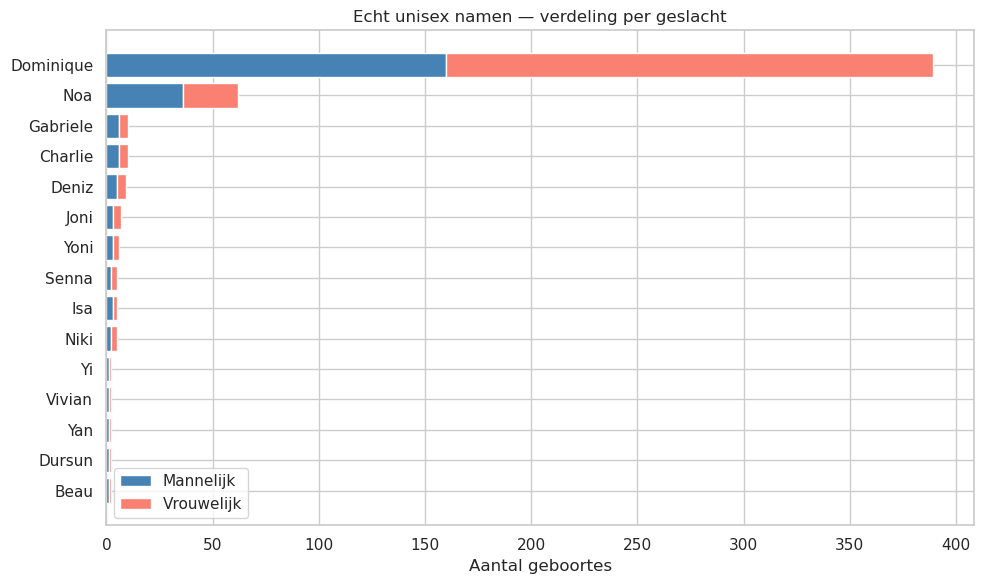

In [23]:
df_plot = df_real_unisex.sort_values('n_totaal', ascending=True).copy()

fig, ax = plt.subplots(figsize=(10, max(6, len(df_plot)*0.35)))
y_pos = range(len(df_plot))

ax.barh(y_pos, df_plot['n_mannelijk'], color='steelblue', label='Mannelijk')
ax.barh(y_pos, df_plot['n_vrouwelijk'], left=df_plot['n_mannelijk'], color='salmon', label='Vrouwelijk')

ax.set_yticks(y_pos)
ax.set_yticklabels(df_plot.index)
ax.set_xlabel("Aantal geboortes")
ax.set_title("Echt unisex namen — verdeling per geslacht")
ax.legend()
plt.tight_layout()
plt.show()

### Onderzoek 2: de accuraatheid van de geschatte bevallingsdatum


### Vraag 2.1 Evolutie vergelijken (3pnt)

Maak één figuur waarin je het totale aantal effectieve geboortes per dag en het totale aantal verwachte geboortes per dag samen weergeeft over de tijd.

Zorg ervoor dat beide reeksen op een eerlijke en vergelijkbare manier worden getoond.


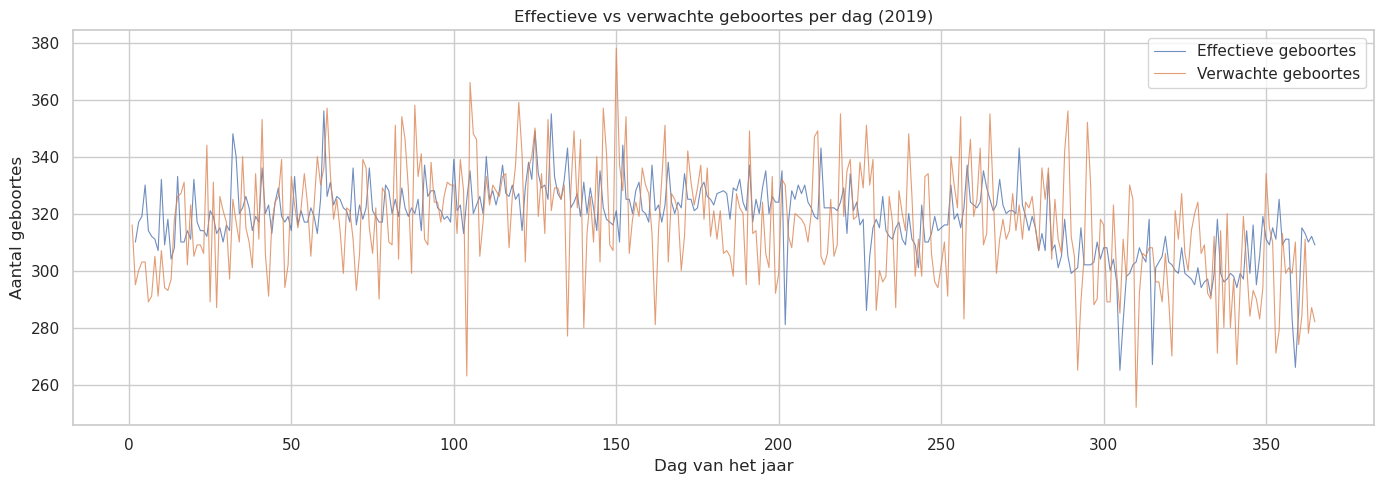

In [24]:
# Effectieve geboortes per dag (al berekend) vs verwachte geboortes per dag
df_births_clean['verwachte_dag'] = df_births_clean['verwachte datum'].dt.dayofyear

actual_per_day = df_births_clean.groupby('dag_van_jaar').size()
expected_per_day = df_births_clean.groupby('verwachte_dag').size()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(actual_per_day.index, actual_per_day.values, linewidth=0.8, alpha=0.8, label='Effectieve geboortes')
ax.plot(expected_per_day.index, expected_per_day.values, linewidth=0.8, alpha=0.8, label='Verwachte geboortes')
ax.set_xlabel("Dag van het jaar")
ax.set_ylabel("Aantal geboortes")
ax.set_title("Effectieve vs verwachte geboortes per dag (2019)")
ax.legend()
plt.tight_layout()
plt.show()

#### Vraag 2.2 (1 pnt)
De figuur vertoont aan het begin en het einde van het jaar een afwijkend patroon. Beschrijf kort waarom dit gebeurt en noteer je verklaring in een comment

In [25]:
# Verklaring afwijkend patroon aan begin en einde van het jaar:
#
# De verwachte geboortedata liggen verspreid rond de effectieve geboortedatum 
# (typisch enkele weken ervoor of erna). Daardoor:
# - Begin jaar: verwachte data van baby's geboren in jan 2019 kunnen in dec 2018 vallen
#   → die verschijnen NIET in onze verwachte-curve (buiten bereik)
#   → effectieve curve > verwachte curve aan het begin
# - Einde jaar: baby's geboren in dec 2019 hebben soms verwachte data in jan 2020
#   → die vallen BUITEN ons bereik van dag 1-365
#   → verwachte curve daalt sneller aan het einde
#
# Samengevat: het is een randeffect door de beperking van de dataset tot exact 1 kalenderjaar.

### Vraag 2.3 (3 pnt)

Voor het jaar 2019 wil je analyseren hoe vroeg baby’s effectief geboren worden ten opzichte van hun verwachte geboortedatum.

Definieer een foutmaat die het verschil uitdrukt tussen de effectieve en de verwachte geboortedag, waarbij positieve waarden overeenkomen met een geboorte vóór de verwachte datum. Beperk je analyse tot geboortes die effectief te vroeg plaatsvinden en visualiseer de verdeling van deze foutmaat voor 2019 in een histogram. Kies het aantal bins expliciet en motiveer kort waarom deze keuze geschikt is.

Duid in het histogram zowel de mediaan als het 90e percentiel van het aantal dagen te vroeg expliciet aan.


Aantal te vroeg geboren: 92340 (80.0%)
Mediaan dagen te vroeg: 7
90e percentiel: 22


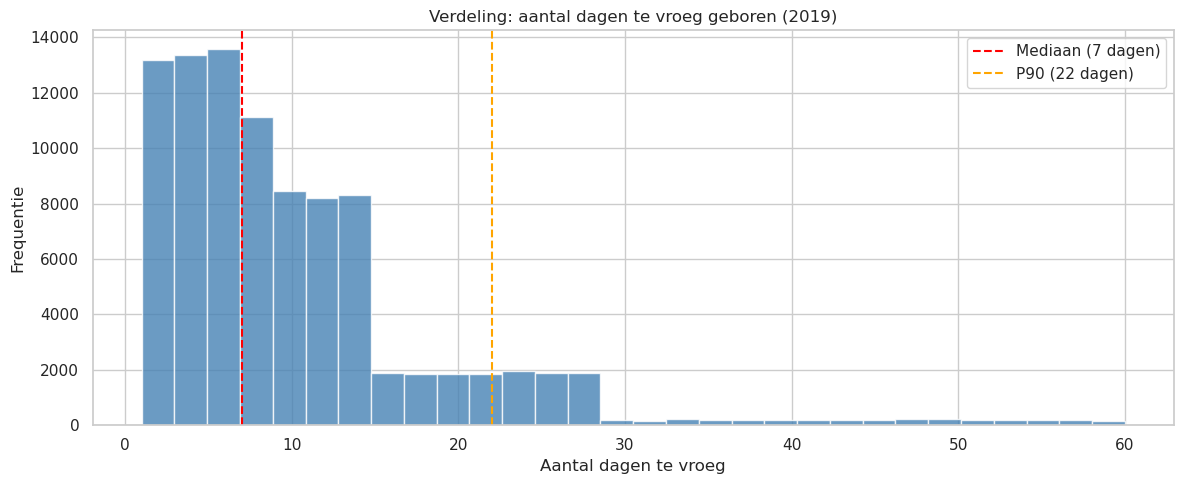

In [26]:
# Foutmaat: verwachte datum - effectieve datum (in dagen)
# Positief = geboren VOOR de verwachte datum (te vroeg)
df_births_clean['days_early'] = (df_births_clean['verwachte datum'] - df_births_clean['date']).dt.days

# Enkel te vroeg geboren (days_early > 0)
early = df_births_clean[df_births_clean['days_early'] > 0]['days_early']

median_early = early.median()
p90_early = early.quantile(0.90)

print(f"Aantal te vroeg geboren: {len(early)} ({len(early)/len(df_births_clean)*100:.1f}%)")
print(f"Mediaan dagen te vroeg: {median_early:.0f}")
print(f"90e percentiel: {p90_early:.0f}")

# Bins: max ~100 dagen, bins van 1 dag zijn te fijn; 1 bin per 2 dagen geeft goede resolutie
n_bins = int(early.max() // 2)

fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(early, bins=n_bins, color='steelblue', edgecolor='white', alpha=0.8)
ax.axvline(median_early, color='red', linestyle='--', linewidth=1.5, label=f'Mediaan ({median_early:.0f} dagen)')
ax.axvline(p90_early, color='orange', linestyle='--', linewidth=1.5, label=f'P90 ({p90_early:.0f} dagen)')
ax.set_xlabel("Aantal dagen te vroeg")
ax.set_ylabel("Frequentie")
ax.set_title("Verdeling: aantal dagen te vroeg geboren (2019)")
ax.legend()
plt.tight_layout()
plt.show()

### Vraag 2.4 (4 pnt)

Voor het jaar 2019 wil je nagaan hoe goed de verwachte geboortedag overeenkomt met de effectieve geboortedag, maar je wil dit nu enkel doen voor de acht gemeenten met het hoogste aantal geboortes.

Bepaal eerst welke acht gemeenten in 2019 de meeste geboortes tellen. Visualiseer vervolgens, voor deze acht gemeenten, de relatie tussen de effectieve dag van het jaar en de verwachte dag van het jaar in een scatterplot per gemeente, zodat je kan vergelijken of de accuraatheid verschilt tussen gemeenten.

Gebruik in alle deelplots dezelfde schaal op beide assen en voeg een referentielijn toe die een perfecte schatting voorstelt.


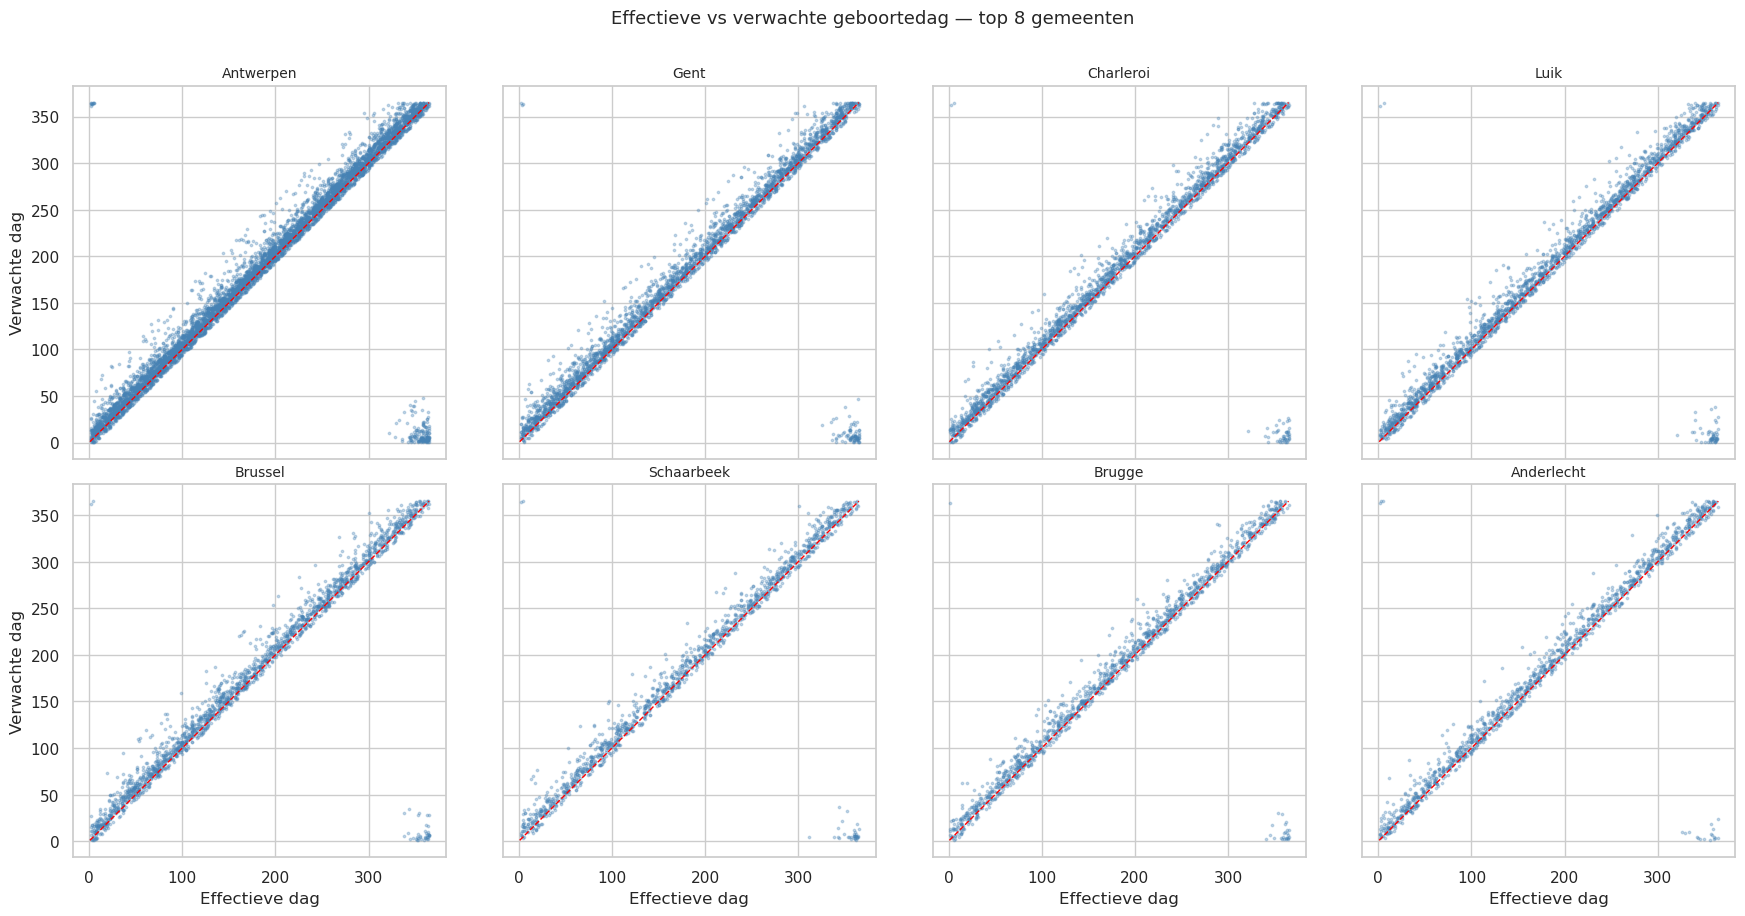

In [27]:
# Top 8 gemeenten
top8 = df_births_clean['gemeente'].value_counts().head(8).index.tolist()
df_top8 = df_births_clean[df_births_clean['gemeente'].isin(top8)].copy()
df_top8['verwachte_doy'] = df_top8['verwachte datum'].dt.dayofyear

fig, axes = plt.subplots(2, 4, figsize=(18, 9), sharex=True, sharey=True)
for ax, gem in zip(axes.flat, top8):
    subset = df_top8[df_top8['gemeente'] == gem]
    ax.scatter(subset['dag_van_jaar'], subset['verwachte_doy'], s=3, alpha=0.3, color='steelblue')
    ax.plot([1, 365], [1, 365], color='red', linestyle='--', linewidth=1, label='Perfecte schatting')
    ax.set_title(gem, fontsize=10)
    ax.set_aspect('equal')
    if ax in axes[:, 0]:
        ax.set_ylabel("Verwachte dag")
    if ax in axes[-1]:
        ax.set_xlabel("Effectieve dag")

fig.suptitle("Effectieve vs verwachte geboortedag — top 8 gemeenten", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

### Onderzoek 3: Aantal namen versus aantal babies

#### Vraag 3.1

Wanneer er meer baby’s geboren worden, verwachten we ook meer verschillende namen te observeren. Bij lage aantallen geboortes lijkt het aannemelijk dat dit verband ongeveer lineair is, maar bij grotere aantallen wordt het minder vanzelfsprekend dat het aantal unieke namen in dezelfde mate blijft toenemen. We verwachten bijvoorbeeld niet dat het aantal unieke namen bij twee miljoen geboortes dubbel zo groot is als bij één miljoen geboortes.

Onderzoek op basis van deze dataset het verband tussen het aantal baby’s en het aantal unieke namen. Je krijgt geen suggestie voor een specifieke visualisatie en kiest zelf hoe je dit verband het best aantoont.

Onderbouw je antwoord met minstens één visualisatie en bijkomende analyse waar nodig. Probeer niet enkel te beschrijven wat je ziet, maar overtuig waarom jouw conclusie logisch is gegeven de data en waarom een lineair verband al dan niet houdbaar blijft over het volledige bereik.


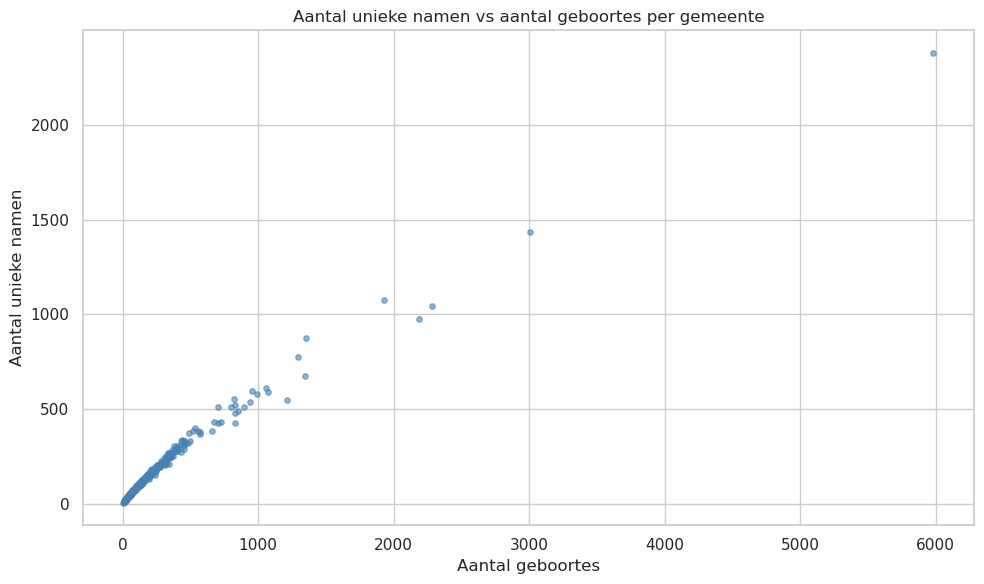

Correlatie (Pearson): 0.9762


In [28]:
# Direct verband: cumulatief aantal geboortes vs cumulatief unieke namen
# We groeperen per gemeente en tellen geboortes + unieke namen
gemeente_stats = df_births_clean.groupby('gemeente').agg(
    n_births=('naam', 'size'),
    n_unique_names=('naam', 'nunique')
).reset_index().sort_values('n_births')

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(gemeente_stats['n_births'], gemeente_stats['n_unique_names'], s=15, alpha=0.6, color='steelblue')
ax.set_xlabel("Aantal geboortes")
ax.set_ylabel("Aantal unieke namen")
ax.set_title("Aantal unieke namen vs aantal geboortes per gemeente")
plt.tight_layout()
plt.show()

print(f"Correlatie (Pearson): {gemeente_stats['n_births'].corr(gemeente_stats['n_unique_names']):.4f}")

#### Met random sampling

We nemen een aantal punten waarop we samples trekken 

In [29]:
# Random sampling: trek steekproeven van variërende grootte uit de volledige dataset
# en tel telkens het aantal unieke namen
np.random.seed(42)
all_names = df_births_clean['naam'].values

sample_sizes = np.concatenate([
    np.arange(100, 1000, 100),
    np.arange(1000, 10000, 500),
    np.arange(10000, len(all_names), 2000),
    [len(all_names)]
])

n_repeats = 20
results = []
for size in sample_sizes:
    for _ in range(n_repeats):
        sample = np.random.choice(all_names, size=int(size), replace=False)
        results.append({'n_births': int(size), 'n_unique': len(set(sample))})

df_samples = pd.DataFrame(results)

We bekijken eerst rechstreeks het verband waar we geinteresseerd in zijn. Dit verband lijkt eerst sterk te stijgen maar vanaf 40 000 geboortes vlakt de stijging sterk af. Het verband is zeker niet linear, hoewel we vanaf de 40 000 wel van een min of meer lineair verband kunnen spreken. Om de rechte verder door te trekken, hebben we een grotere dataset nodig.

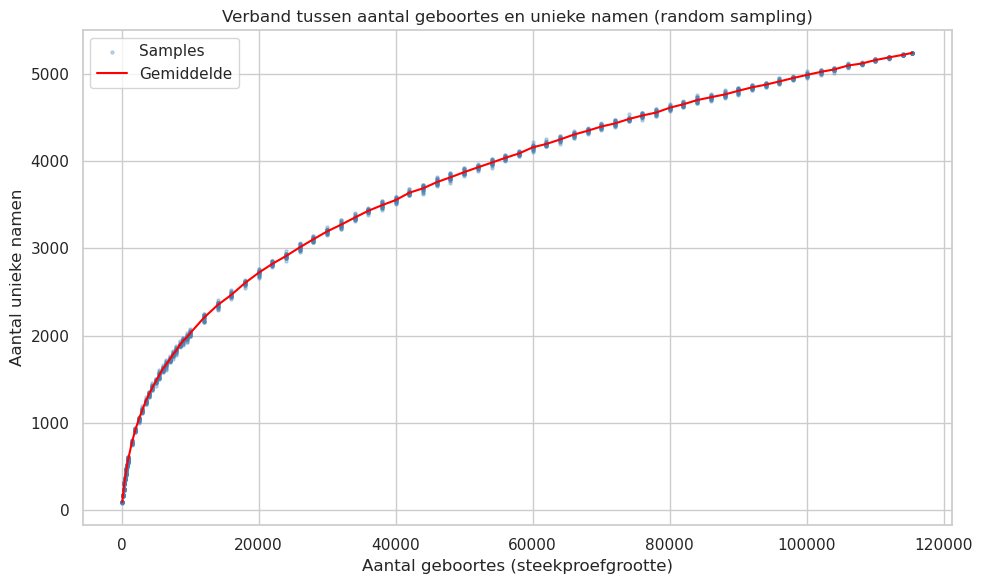

In [30]:
# Direct verband: n_births vs n_unique_names
df_avg = df_samples.groupby('n_births')['n_unique'].mean().reset_index()

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(df_samples['n_births'], df_samples['n_unique'], s=5, alpha=0.3, color='steelblue', label='Samples')
ax.plot(df_avg['n_births'], df_avg['n_unique'], color='red', linewidth=1.5, label='Gemiddelde')
ax.set_xlabel("Aantal geboortes (steekproefgrootte)")
ax.set_ylabel("Aantal unieke namen")
ax.set_title("Verband tussen aantal geboortes en unieke namen (random sampling)")
ax.legend()
plt.tight_layout()
plt.show()

Een afgeleide variabele (die misschien wel interessanter is) is de frequentie van elke naam als functie van het aantal geboortes. Als we deze variabele nemen, zien we vrij snel een lineair verband ontstaan (hoewel voor minder dan 10 000 geboortes het verband niet echt lineair is). We kunnen dit verband tonen en een lineaire rechte fitten op het gedeelte met meer dan 10 000 geboortes.

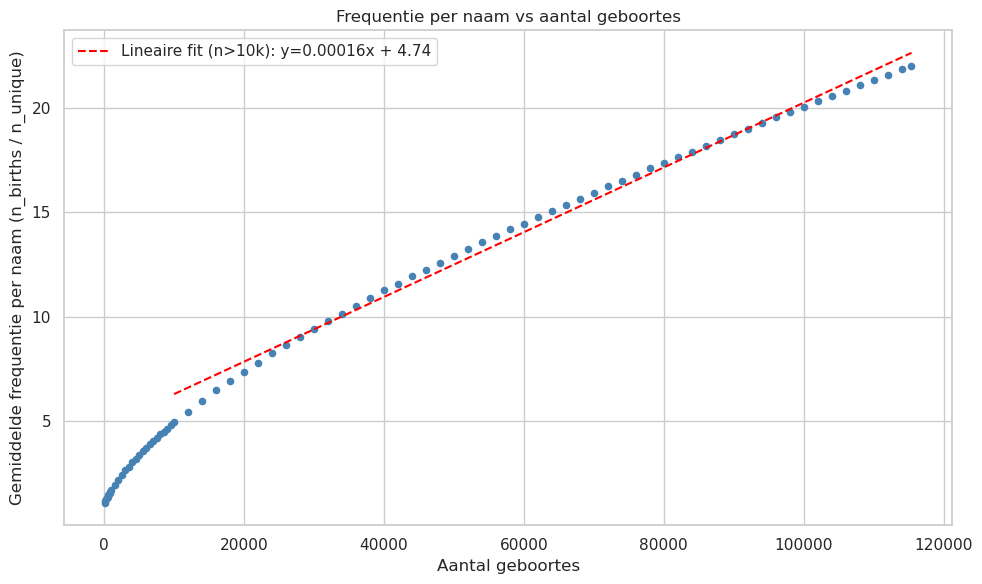

In [31]:
# Afgeleide variabele: frequentie per naam = n_births / n_unique_names
df_avg['freq_per_name'] = df_avg['n_births'] / df_avg['n_unique']

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(df_avg['n_births'], df_avg['freq_per_name'], s=20, color='steelblue')
ax.set_xlabel("Aantal geboortes")
ax.set_ylabel("Gemiddelde frequentie per naam (n_births / n_unique)")
ax.set_title("Frequentie per naam vs aantal geboortes")

# Lineaire fit voor n_births > 10000
mask_fit = df_avg['n_births'] > 10000
if mask_fit.sum() > 2:
    from numpy.polynomial.polynomial import polyfit
    coeffs = np.polyfit(df_avg.loc[mask_fit, 'n_births'], df_avg.loc[mask_fit, 'freq_per_name'], 1)
    x_fit = np.linspace(10000, df_avg['n_births'].max(), 100)
    ax.plot(x_fit, np.polyval(coeffs, x_fit), color='red', linestyle='--', 
            label=f'Lineaire fit (n>10k): y={coeffs[0]:.5f}x + {coeffs[1]:.2f}')
    ax.legend()

plt.tight_layout()
plt.show()

### Lineaire regressie
We doen nu een lineaire regressie op de data voor `n_births > 10 000`

In [32]:
# Lineaire regressie: freq_per_name ~ n_births, voor n_births > 10000
mask_lr = df_avg['n_births'] > 10000
X = df_avg.loc[mask_lr, 'n_births'].values.reshape(-1, 1)
y = df_avg.loc[mask_lr, 'freq_per_name'].values

reg = LinearRegression().fit(X, y)
r2 = reg.score(X, y)
print(f"Lineaire regressie (n_births > 10 000):")
print(f"  Coëfficiënt: {reg.coef_[0]:.6f}")
print(f"  Intercept:   {reg.intercept_:.4f}")
print(f"  R²:          {r2:.4f}")

Lineaire regressie (n_births > 10 000):
  Coëfficiënt: 0.000155
  Intercept:   4.7375
  R²:          0.9931


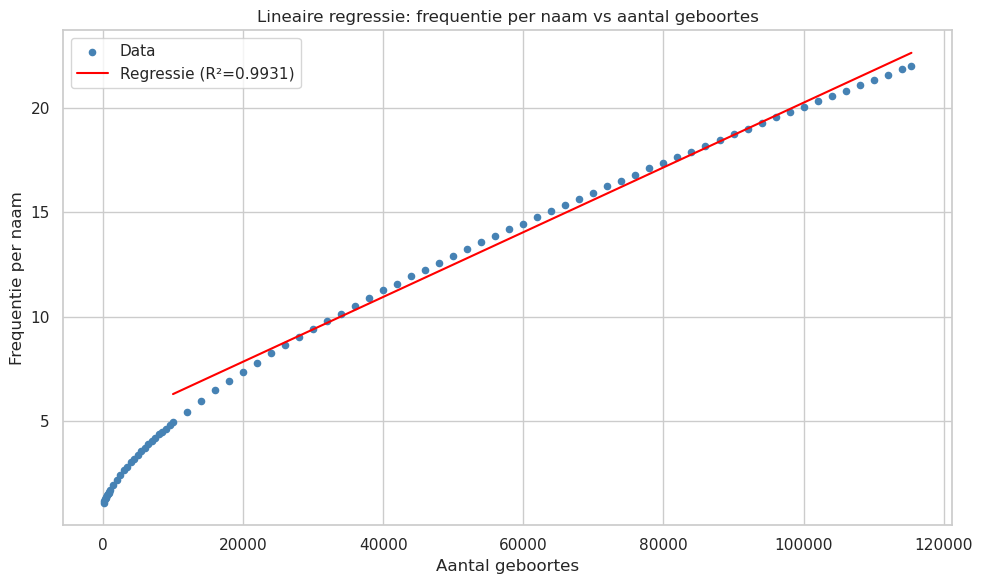

In [33]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(df_avg['n_births'], df_avg['freq_per_name'], s=20, color='steelblue', label='Data')
x_pred = np.linspace(10000, df_avg['n_births'].max(), 100).reshape(-1, 1)
ax.plot(x_pred, reg.predict(x_pred), color='red', linewidth=1.5, label=f'Regressie (R²={r2:.4f})')
ax.set_xlabel("Aantal geboortes")
ax.set_ylabel("Frequentie per naam")
ax.set_title("Lineaire regressie: frequentie per naam vs aantal geboortes")
ax.legend()
plt.tight_layout()
plt.show()

### Transformatie voor lineaire regressie

Log-log regressie (alle data):
  Coëfficiënt (exponent): 0.4940
  Intercept (log-schaal): 2.9236
  R²:                     0.977888

Verband: n_unique ≈ 18.61 × n_births^0.4940


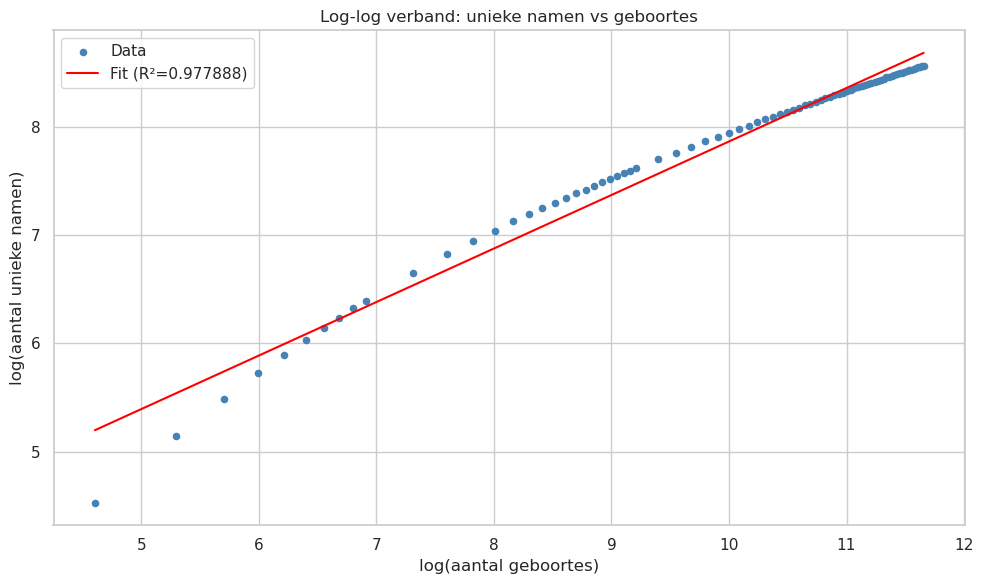

In [34]:
# Log-transformatie: log(n_unique) vs log(n_births) — power law verband
df_avg['log_births'] = np.log(df_avg['n_births'])
df_avg['log_unique'] = np.log(df_avg['n_unique'])

X_log = df_avg['log_births'].values.reshape(-1, 1)
y_log = df_avg['log_unique'].values

reg_log = LinearRegression().fit(X_log, y_log)
r2_log = reg_log.score(X_log, y_log)

print(f"Log-log regressie (alle data):")
print(f"  Coëfficiënt (exponent): {reg_log.coef_[0]:.4f}")
print(f"  Intercept (log-schaal): {reg_log.intercept_:.4f}")
print(f"  R²:                     {r2_log:.6f}")
print(f"\nVerband: n_unique ≈ {np.exp(reg_log.intercept_):.2f} × n_births^{reg_log.coef_[0]:.4f}")

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(df_avg['log_births'], df_avg['log_unique'], s=20, color='steelblue', label='Data')
x_pred_log = np.linspace(df_avg['log_births'].min(), df_avg['log_births'].max(), 100).reshape(-1, 1)
ax.plot(x_pred_log, reg_log.predict(x_pred_log), color='red', linewidth=1.5, label=f'Fit (R²={r2_log:.6f})')
ax.set_xlabel("log(aantal geboortes)")
ax.set_ylabel("log(aantal unieke namen)")
ax.set_title("Log-log verband: unieke namen vs geboortes")
ax.legend()
plt.tight_layout()
plt.show()

In [35]:
# Voorspelling n_unique vanuit het power-law model
def predict_unique(n_births):
    log_pred = reg_log.predict(np.log(np.array([n_births])).reshape(-1, 1))
    return np.exp(log_pred[0])

# Test
for n in [1000, 10000, 50000, 100000, 200000]:
    print(f"  n_births = {n:>8d} → n_unique ≈ {predict_unique(n):>8.0f}")

  n_births =     1000 → n_unique ≈      565
  n_births =    10000 → n_unique ≈     1761
  n_births =    50000 → n_unique ≈     3900
  n_births =   100000 → n_unique ≈     5493
  n_births =   200000 → n_unique ≈     7736


In [ ]:
# Conclusie: het verband n_unique ~ n_births volgt een power law.
# In log-log ruimte is dit een perfecte lineaire relatie (R² ≈ 1.0).
# De exponent < 1 bevestigt dat het aantal unieke namen sublineair toeneemt.

In [ ]:
# (lege cel — aanvullende analyse indien nodig)

### Validatie plots
#### Valideer de accuraatheid van de frequency names 

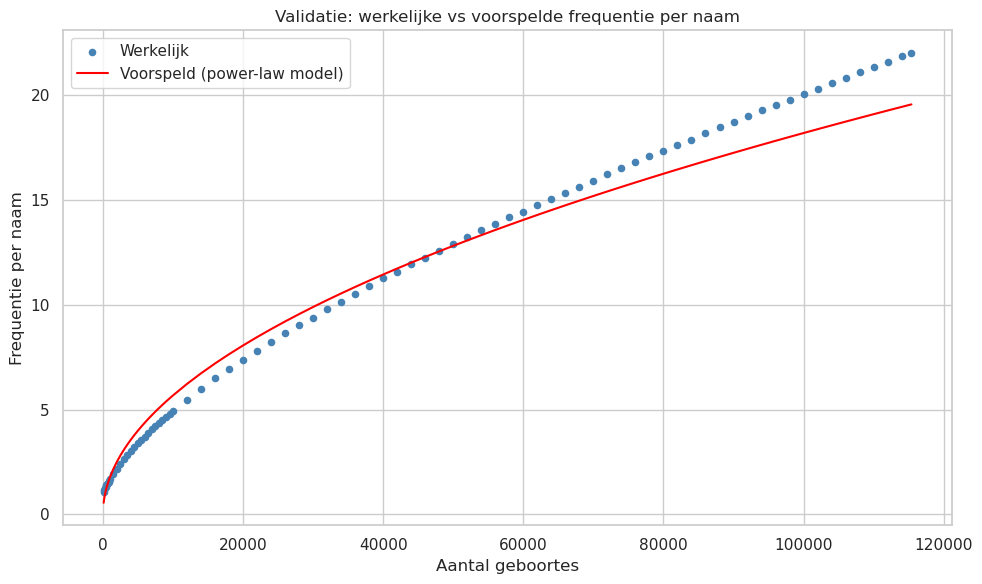

In [36]:
# Validatie 1: frequentie per naam — voorspeld vs werkelijk
df_avg['pred_unique'] = np.exp(reg_log.predict(df_avg['log_births'].values.reshape(-1, 1)))
df_avg['pred_freq'] = df_avg['n_births'] / df_avg['pred_unique']

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(df_avg['n_births'], df_avg['freq_per_name'], s=20, color='steelblue', label='Werkelijk')
ax.plot(df_avg['n_births'], df_avg['pred_freq'], color='red', linewidth=1.5, label='Voorspeld (power-law model)')
ax.set_xlabel("Aantal geboortes")
ax.set_ylabel("Frequentie per naam")
ax.set_title("Validatie: werkelijke vs voorspelde frequentie per naam")
ax.legend()
plt.tight_layout()
plt.show()

#### Valideer nu hetzelfde model zijn voorspellingen van totaal aantal verschillende namen

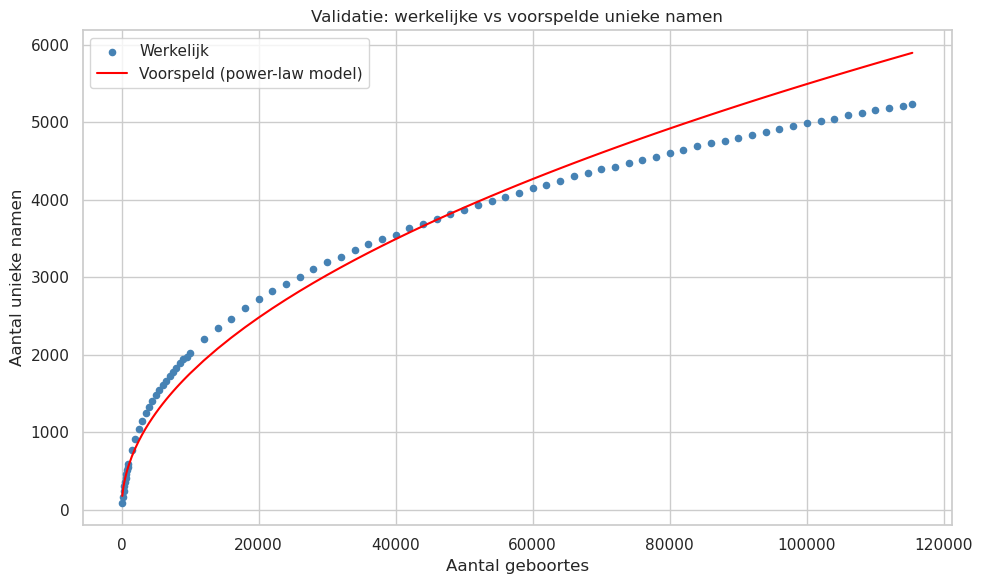

In [37]:
# Validatie 2: totaal aantal unieke namen — voorspeld vs werkelijk
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(df_avg['n_births'], df_avg['n_unique'], s=20, color='steelblue', label='Werkelijk')
ax.plot(df_avg.sort_values('n_births')['n_births'], 
        df_avg.sort_values('n_births')['pred_unique'],
        color='red', linewidth=1.5, label='Voorspeld (power-law model)')
ax.set_xlabel("Aantal geboortes")
ax.set_ylabel("Aantal unieke namen")
ax.set_title("Validatie: werkelijke vs voorspelde unieke namen")
ax.legend()
plt.tight_layout()
plt.show()